In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

bbox = pd.read_csv("/content/drive/MyDrive/INTRO2AI/annotation.csv")
bbox.head(), bbox.shape

(         filename  xmin  ymin  xmax  ymax
 0  image_0000.jpg   534   360   663   504
 1  image_0001.jpg   400   249   595   573
 2  image_0002.jpg   474   254   678   468
 3  image_0003.jpg   422   347   546   475
 4  image_0004.jpg   222   458   447   675,
 (653, 5))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

class Img:
    def __init__(self, name):
        super().__init__()
        self.img = Image.open('/content/drive/MyDrive/INTRO2AI/train/' + name)
        info = bbox[bbox['filename'] == name].iloc[0]
        self.bbox = [info['xmin'],
                     info['ymin'],
                     info['xmax'],
                     info['ymax']]


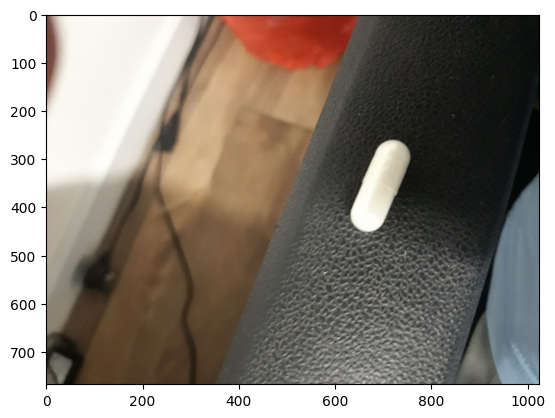

(None, [np.int64(621), np.int64(237), np.int64(762), np.int64(467)])

In [ ]:
img = Img("image_0111.jpg")
plt.imshow(img.img)
plt.show(), img.bbox


In [ ]:
import torchvision.transforms.functional as F

def crop_xyxy(img, x1, y1, x2, y2):
    # img: PIL hoặc Tensor (C,H,W)
    left = int(x1)
    top = int(y1)
    width = int(x2 - x1)
    height = int(y2 - y1)
    return F.crop(img, top=top, left=left, height=height, width=width)


In [ ]:
a = crop_xyxy(img.img, *img.bbox)

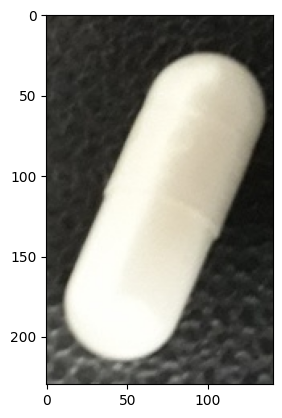

In [ ]:
plt.imshow(a)
plt.show()

In [ ]:
import random
import torchvision.transforms.functional as F

def random_crop_keep_bbox(
    img,
    bbox,              # (x1,y1,x2,y2)
    out_size=1024,
    scale=(0.6, 1.0)
):
    W, H = img.size
    x1, y1, x2, y2 = bbox

    bbox_w = x2 - x1
    bbox_h = y2 - y1

    # 1. random crop size (nhưng phải >= bbox)
    s = random.uniform(*scale)
    crop_w = max(int(W * s), bbox_w)
    crop_h = max(int(H * s), bbox_h)

    crop_w = min(crop_w, W)
    crop_h = min(crop_h, H)

    # 2. random top-left nhưng phải chứa bbox
    left_min = max(0, x2 - crop_w)
    left_max = min(x1, W - crop_w)

    top_min  = max(0, y2 - crop_h)
    top_max  = min(y1, H - crop_h)

    left = random.randint(left_min, left_max)
    top  = random.randint(top_min, top_max)

    # 3. crop image
    img = F.crop(img, top, left, crop_h, crop_w)

    # 4. update bbox
    new_bbox = (
        x1 - left,
        y1 - top,
        x2 - left,
        y2 - top
    )

    # 5. resize
    img = F.resize(img, (out_size, out_size))

    scale_x = out_size / crop_w
    scale_y = out_size / crop_h

    new_bbox = (
        new_bbox[0] * scale_x,
        new_bbox[1] * scale_y,
        new_bbox[2] * scale_x,
        new_bbox[3] * scale_y
    )

    return img, new_bbox


In [ ]:
a, _ = random_crop_keep_bbox(img.img, img.bbox, scale = (0.4, 1.0))
plt.imshow(a)
plt.show()